In [1]:
# %% Cell 1 - Imports
import sys
from pathlib import Path

import casadi as ca
import numpy as np

PROJECT_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
if not (PROJECT_DIR / "mobile_robot_helpers.py").exists():
    PROJECT_DIR = Path("projects/project_2_mobile_robot_corridor").resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from mobile_robot_helpers import (
    CorridorParams,
    discretize_continuous_system,
    dlqr,
    eta_bounds_horizon,
    global_state_from_error,
    nominal_tracking_controller,
    phi_sequence,
    plot_corridor_preview,
    plot_eta_history,
    plot_input_history,
    plot_top_view,
    print_summary_table,
    tracking_error,
    unicycle_step,
)


## 1. Imports and path setup
This notebook is part of Project 2, the mobile robot corridor example. The first cell only prepares Python imports and makes the notebook robust to common VS Code and Jupyter working-directory choices.

The helper file in this folder contains plotting, path-dependent corridor bounds, and summary metrics. Those details are useful for the project, but they are not the main MPC idea.


## 2. Model and project context
The mobile robot follows a circular reference trajectory. A nominal nonlinear tracking controller and inner loop are assumed to already exist. Around the reference trajectory, we use a constant local linear error model as the prediction model for MPC.

The MPC state is the local tracking error

$$
e_k =
\begin{bmatrix}
\tilde{\xi}_k \\
\tilde{\eta}_k \\
\tilde{\psi}_k
\end{bmatrix}.
$$

Here, $\tilde{\xi}$ is longitudinal error, $\tilde{\eta}$ is lateral error, and $\tilde{\psi}$ is heading error. The MPC input is an additive correction

$$
u_{e,k} =
\begin{bmatrix}
v_{e,k} \\
\omega_{e,k}
\end{bmatrix}.
$$

Conceptually, the robot input is the nominal tracking command plus this correction:

$$
u_k = u_{c,k} + u_{e,k}.
$$

The notebook focuses on the predictive correction layer. Since the reference is a circle, $v_r$ and $\omega_r$ are constant, so the local model is constant:

$$
\dot e = A_c e + B_c u_e.
$$

After discretization, all controllers use

$$
e_{k+1} = A_d e_k + B_d u_{e,k}.
$$

The continuous-time matrices used here are

$$
A_c =
\begin{bmatrix}
-K_\xi & \omega_r & 0 \\
-\omega_r & 0 & v_r \\
0 & -v_r K_\eta & -v_r K_\psi
\end{bmatrix},
\qquad
B_c =
\begin{bmatrix}
1 & 0 \\
0 & 0 \\
0 & 1
\end{bmatrix}.
$$



In [2]:
# %% Cell 2 - Project parameters
Ts = 0.1
steps = 100
N = 40

radius = 1.8
v_r = 0.45
omega_r = v_r / radius
phi0 = 0.70

K_xi = 1.0
K_eta = 2.0
K_psi = 2.0

nx = 3
nu = 2

x0 = np.array([0.0, -0.15, 0.0])
z0 = global_state_from_error(x0, phi0, radius)


The next cell writes the continuous-time local error model explicitly, discretizes it, and computes the LQR terminal matrix used later by MPC.

The code uses compact array names, but the mathematical prediction model is the one above: $e_{k+1}=A_d e_k+B_d u_{e,k}$.


In [3]:
# %% Cell 3 - Constant local prediction model for MPC and LQR correction
A_c = np.array(
    [
        [-K_xi, omega_r, 0.0],
        [-omega_r, 0.0, v_r],
        [0.0, -v_r * K_eta, -v_r * K_psi],
    ]
)

B_c = np.array(
    [
        [1.0, 0.0],
        [0.0, 0.0],
        [0.0, 1.0],
    ]
)

A, B = discretize_continuous_system(A_c, B_c, Ts)

Q = np.diag([0.5, 8.0, 1.0])
R = np.diag([0.15, 0.08])
K_lqr, P_inf = dlqr(A, B, Q, R)

u_min = np.array([-0.30, -1.20])
u_max = np.array([0.30, 1.20])


### Known path-dependent corridor

The narrowed passage is known from the path variable $\phi$ along the circular reference. The lateral error must satisfy a path-dependent box:

$$
\eta_{\min}(\phi_k)
\le
\tilde{\eta}_k
\le
\eta_{\max}(\phi_k).
$$

Outside the narrowed section, the corridor is wide around the reference. Inside the narrowed section, the admissible box is shifted toward positive lateral error, so simply tracking $\tilde{\eta}=0$ is no longer enough.

For the current time step, future path values are computed from constant circular motion:

$$
\phi_{k+j} = \phi_k + j T_s \omega_r,
\qquad j=0,\dots,N.
$$

The helper returns the corresponding future arrays $\eta_{\min}$ and $\eta_{\max}$. The notebook should focus on what MPC does with these bounds, not on obstacle perception or path planning.



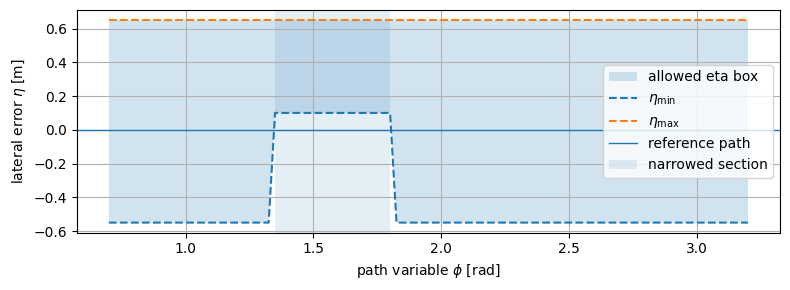

In [4]:
# %% Cell 4 - Known path-dependent lateral constraints
corridor = CorridorParams(
    phi_center=np.pi / 2.0,
    phi_half_width=0.24,
    eta_min_normal=-0.55,
    eta_max_normal=0.65,
    eta_min_narrow=0.10,
    eta_max_narrow=0.65,
)

phi_values = phi_sequence(phi0, omega_r, Ts, steps)
plot_corridor_preview(phi_values, corridor)


## 3. Nominal nonlinear rollout
First, we simulate the actual nonlinear rover kinematics with the nominal tracking controller and no additive correction:

$$
u_{e,k}=0.$$

At each time step we compute the tracking error from the global rover state, evaluate the nonlinear nominal controller, and apply the resulting total input to the nonlinear model. This is the realistic loop. The linear error model is not used for the plant simulation here.

This baseline shows what happens when the tracking controller regulates the error toward zero but has no preview of the shifted corridor.


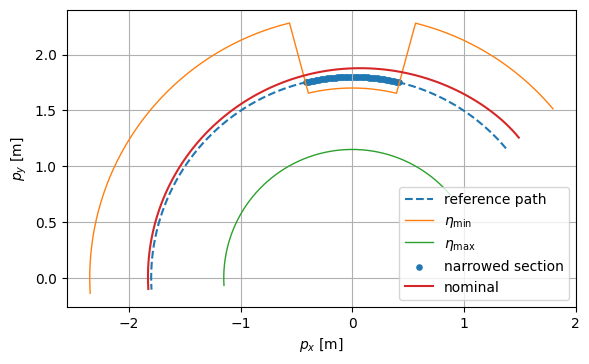

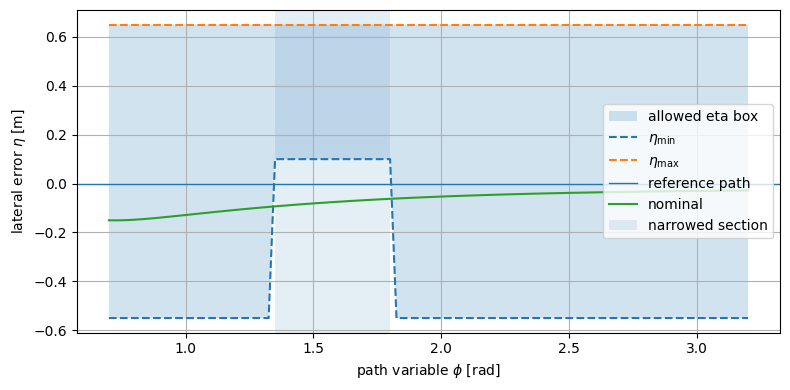

controller              min eta margin    final |e|      max |u_e|
----------------------------------------------------------------
nominal                         -0.193        0.032        0.000


In [5]:
# %% Cell 5 - Nominal nonlinear closed-loop motion, without MPC correction
z_nominal = np.zeros((steps + 1, nx))
x_nominal = np.zeros((steps + 1, nx))
u_nominal = np.zeros((steps, nu))
z_nominal[0] = z0
x_nominal[0] = tracking_error(z_nominal[0], phi_values[0], radius)

for k in range(steps):
    x_k = tracking_error(z_nominal[k], phi_values[k], radius)
    u_c = nominal_tracking_controller(x_k, v_r, omega_r, K_xi, K_eta, K_psi)
    u_e = np.zeros(nu)

    z_nominal[k + 1] = unicycle_step(z_nominal[k], u_c + u_e, Ts)
    x_nominal[k] = x_k
    u_nominal[k] = u_e

x_nominal[-1] = tracking_error(z_nominal[-1], phi_values[-1], radius)
nominal_result = {"x": x_nominal, "z": z_nominal, "u": u_nominal}

plot_top_view({"nominal": nominal_result}, phi_values, corridor, radius)
plot_eta_history({"nominal": nominal_result}, phi_values, corridor)
print_summary_table({"nominal": nominal_result}, phi_values, corridor)


## 4. LQR correction in the nonlinear loop
The second baseline computes a correction from the local linear model,

$$u_{e,k}=-K e_k,$$

but applies the total input

$$u_k = u_{c,k} + u_{e,k}$$

to the nonlinear rover model. LQR improves local error convergence, but it still drives the error toward zero. It does not know that the corridor becomes shifted later. This makes it a useful comparison to MPC: both use the same local correction state, but only MPC sees the future path-dependent constraint.


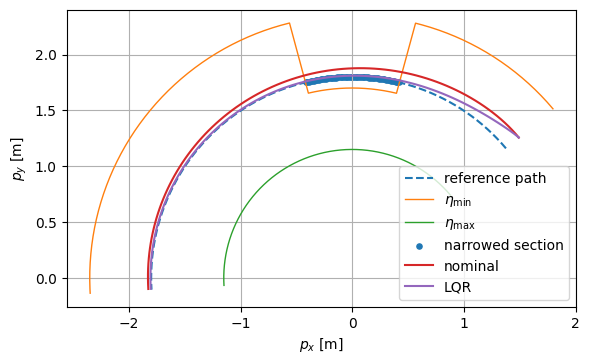

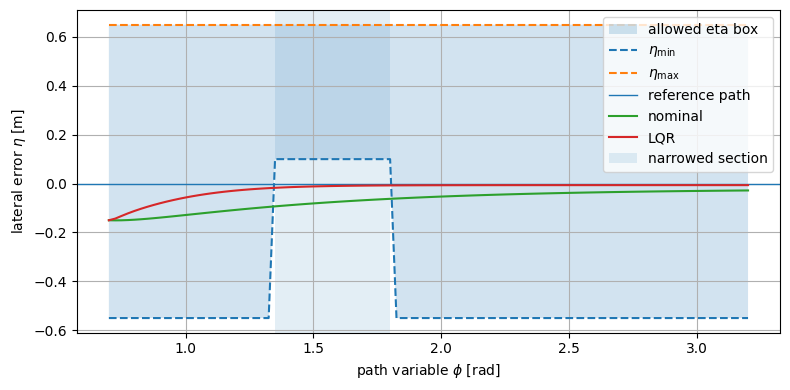

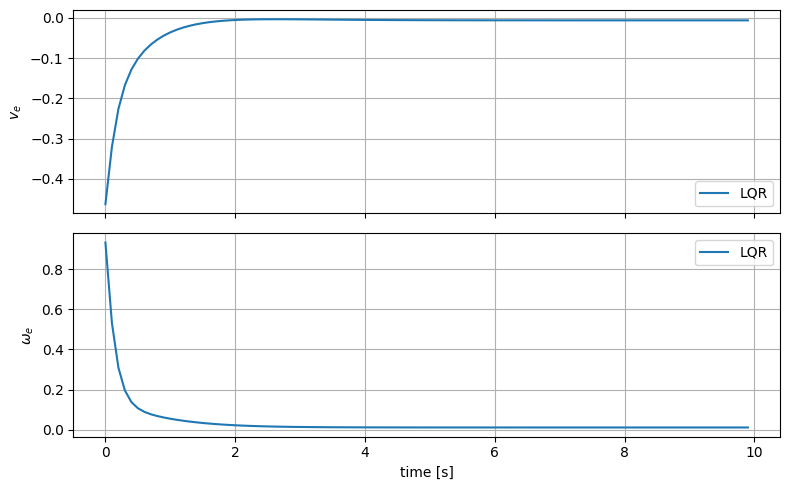

controller              min eta margin    final |e|      max |u_e|
----------------------------------------------------------------
nominal                         -0.193        0.032        0.000
LQR                             -0.117        0.013        1.043


In [6]:
# %% Cell 6 - LQR correction applied to the nonlinear loop
z_lqr = np.zeros((steps + 1, nx))
x_lqr = np.zeros((steps + 1, nx))
u_lqr = np.zeros((steps, nu))
z_lqr[0] = z0
x_lqr[0] = tracking_error(z_lqr[0], phi_values[0], radius)

for k in range(steps):
    x_k = tracking_error(z_lqr[k], phi_values[k], radius)
    u_c = nominal_tracking_controller(x_k, v_r, omega_r, K_xi, K_eta, K_psi)
    u_e = -K_lqr @ x_k

    z_lqr[k + 1] = unicycle_step(z_lqr[k], u_c + u_e, Ts)
    x_lqr[k] = x_k
    u_lqr[k] = u_e

x_lqr[-1] = tracking_error(z_lqr[-1], phi_values[-1], radius)

baseline_results = {
    "nominal": nominal_result,
    "LQR": {"x": x_lqr, "z": z_lqr, "u": u_lqr},
}

plot_top_view(baseline_results, phi_values, corridor, radius)
plot_eta_history(baseline_results, phi_values, corridor)
plot_input_history({"LQR": baseline_results["LQR"]}, Ts)
print_summary_table(baseline_results, phi_values, corridor)



## 5. MPC formulation
The MPC controller uses the same model and input limits, but it also includes the future lateral corridor box. Inside the horizon implementation, $j$ denotes the local prediction index:

$$
e_{j+1}=A_d e_j+B_d u_{e,j}.
$$

The finite-horizon cost is

$$
J_N =
\sum_{j=0}^{N-1}
\left(
e_j^\top Q e_j
+
u_{e,j}^\top R u_{e,j}
\right)
+
e_N^\top P_\infty e_N.
$$

The input constraints are hard box constraints:

$$
u_{\min} \le u_{e,j} \le u_{\max},
\qquad j=0,\dots,N-1.
$$

The corridor constraints are also hard constraints:

$$
\eta_{\min,j}
\le
e_{j,\eta}
\le
\eta_{\max,j},
\qquad j=1,\dots,N.
$$

The current measured state is fixed; the optimizer constrains the predicted future states. There are no slack variables in the main Project 2 MPC. If the corridor is made infeasible, the solver should report failure instead of hiding it with a fallback controller.


In [7]:
# %% Cell 7 - CasADi MPC correction solver

def solve_mpc_correction(x_meas, phi_k):
    opti = ca.Opti()

    U = opti.variable(nu, N)

    A_ca = ca.DM(A)
    B_ca = ca.DM(B)
    Q_ca = ca.DM(Q)
    R_ca = ca.DM(R)
    P_ca = ca.DM(P_inf)
    x0_ca = ca.DM(x_meas)

    _, eta_min_h, eta_max_h, _ = eta_bounds_horizon(phi_k, omega_r, Ts, N, corridor)

    X = [x0_ca]
    cost = 0

    for j in range(N):
        x_j = X[j]
        u_j = U[:, j]

        cost += ca.mtimes([x_j.T, Q_ca, x_j])
        cost += ca.mtimes([u_j.T, R_ca, u_j])

        opti.subject_to(opti.bounded(float(u_min[0]), U[0, j], float(u_max[0])))
        opti.subject_to(opti.bounded(float(u_min[1]), U[1, j], float(u_max[1])))

        x_next = A_ca @ x_j + B_ca @ u_j
        X.append(x_next)

        opti.subject_to(x_next[1] >= float(eta_min_h[j + 1]))
        opti.subject_to(x_next[1] <= float(eta_max_h[j + 1]))

    x_N = X[N]
    cost += ca.mtimes([x_N.T, P_ca, x_N])

    opti.minimize(cost)
    opti.set_initial(U, 0.0)
    opti.solver("ipopt", {"print_time": False}, {"print_level": 0})

    sol = opti.solve()

    U_opt = np.array(sol.value(U)).T
    X_opt = np.zeros((N + 1, nx))
    X_opt[0] = x_meas
    for j in range(N):
        X_opt[j + 1] = A @ X_opt[j] + B @ U_opt[j]

    return {
        "u0": U_opt[0],
        "U": U_opt,
        "X": X_opt,
        "status": opti.stats()["return_status"],
    }


## 6. MPC correction in the nonlinear loop
The MPC controller is used in receding-horizon form:

1. measure the current global rover state,
2. compute the current tracking error $e_k$,
3. compute future path values $\phi_k,\dots,\phi_{k+N}$,
4. solve the finite-horizon hard-constrained MPC problem on the local linear error model,
5. apply only the first correction input $u_{e,k}$,
6. add it to the nonlinear nominal controller,
7. simulate one step of the nonlinear rover kinematics.

So the MPC prediction model is linear, but the closed-loop simulation remains the nonlinear engineering loop.



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



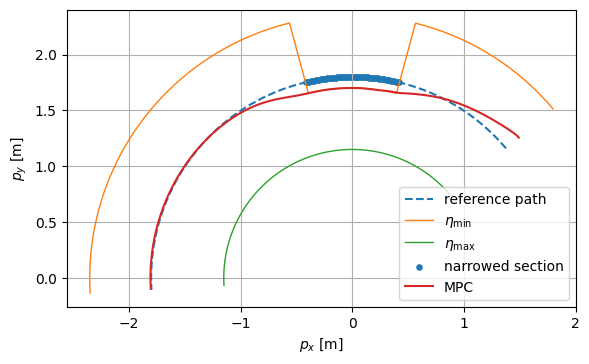

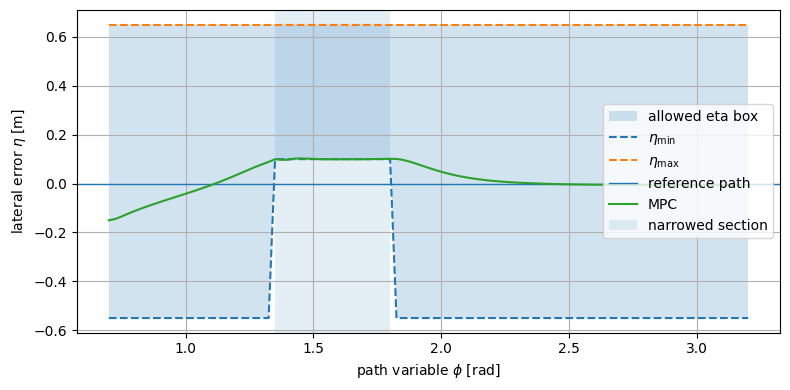

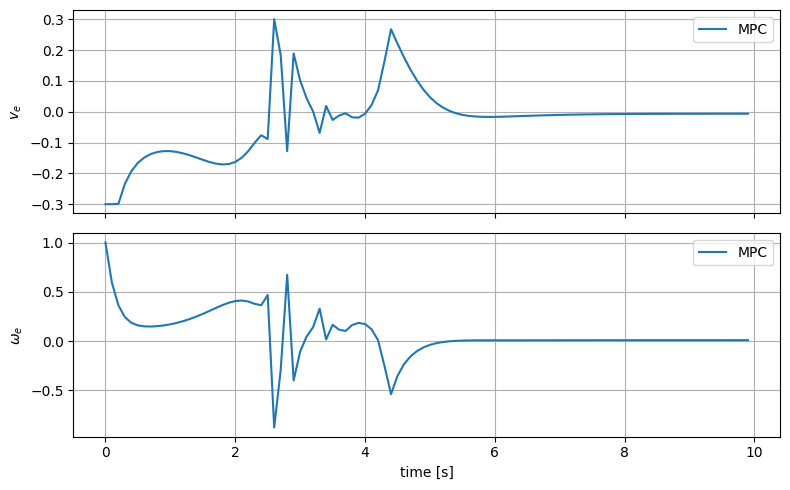

controller              min eta margin    final |e|      max |u_e|
----------------------------------------------------------------
MPC                             -0.003        0.013        1.045


In [8]:
# %% Cell 8 - MPC correction applied to the nonlinear loop
z_mpc = np.zeros((steps + 1, nx))
x_mpc = np.zeros((steps + 1, nx))
u_mpc = np.zeros((steps, nu))
mpc_status = []
z_mpc[0] = z0
x_mpc[0] = tracking_error(z_mpc[0], phi_values[0], radius)

for k in range(steps):
    phi_k = phi_values[k]
    x_k = tracking_error(z_mpc[k], phi_k, radius)
    result = solve_mpc_correction(x_k, phi_k)

    u_c = nominal_tracking_controller(x_k, v_r, omega_r, K_xi, K_eta, K_psi)
    u_e = result["u0"]

    z_mpc[k + 1] = unicycle_step(z_mpc[k], u_c + u_e, Ts)
    x_mpc[k] = x_k
    u_mpc[k] = u_e
    mpc_status.append(result["status"])

x_mpc[-1] = tracking_error(z_mpc[-1], phi_values[-1], radius)
mpc_result = {"x": x_mpc, "z": z_mpc, "u": u_mpc, "status": mpc_status}

plot_top_view({"MPC": mpc_result}, phi_values, corridor, radius)
plot_eta_history({"MPC": mpc_result}, phi_values, corridor)
plot_input_history({"MPC": mpc_result}, Ts)
print_summary_table({"MPC": mpc_result}, phi_values, corridor)


## 7. Final comparison and interpretation
The final plots compare nominal nonlinear tracking, LQR correction, and MPC correction.

The top-view plot gives the engineering interpretation. The lateral-error plot is the main MPC plot because it shows $	ilde{\eta}_k$ against the path-dependent limits $\eta_{\min}(\phi_k)$ and $\eta_{\max}(\phi_k)$.

The summary table reports the minimum lateral corridor margin:

$$
\min_k
\left(
	\tilde{\eta}_k - \eta_{\min}(\phi_k),
\eta_{\max}(\phi_k) - 	\tilde{\eta}_k
\right).
$$

A negative margin means that the controller entered the forbidden part of the local corridor. A nonnegative margin means that the hard box constraint was respected along the simulated trajectory.


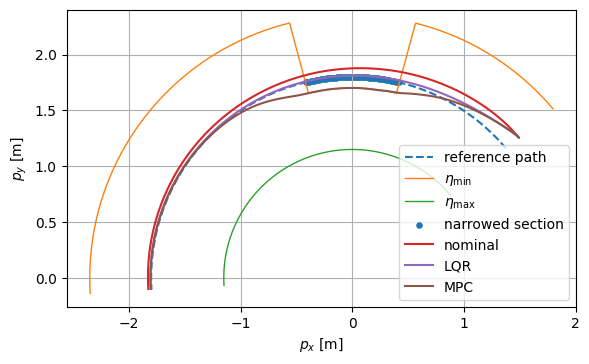

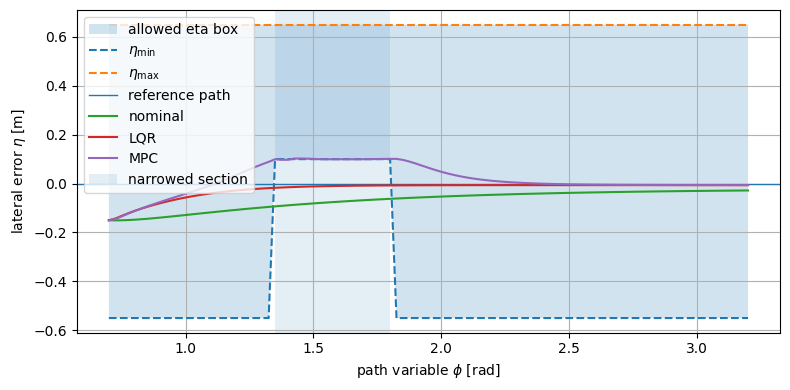

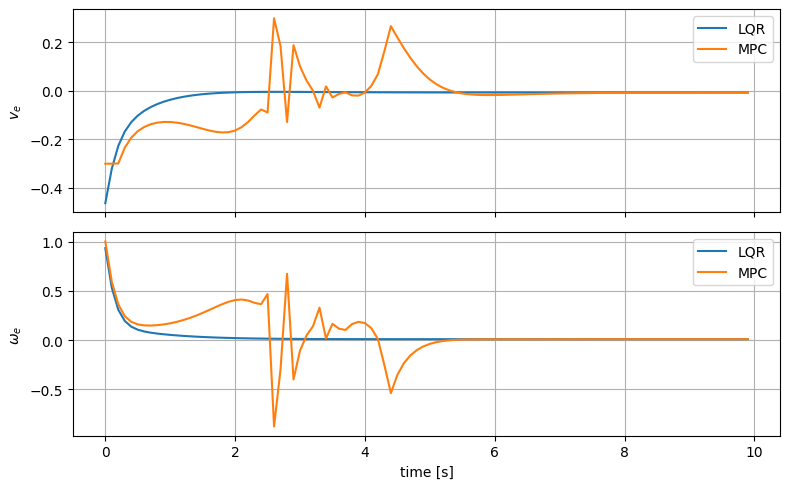

controller              min eta margin    final |e|      max |u_e|
----------------------------------------------------------------
nominal                         -0.193        0.032        0.000
LQR                             -0.117        0.013        1.043
MPC                             -0.003        0.013        1.045


In [9]:
# %% Cell 9 - Final comparison
all_results = {
    "nominal": nominal_result,
    "LQR": baseline_results["LQR"],
    "MPC": mpc_result,
}

plot_top_view(all_results, phi_values, corridor, radius)
plot_eta_history(all_results, phi_values, corridor)
plot_input_history(
    {
        "LQR": baseline_results["LQR"],
        "MPC": mpc_result,
    },
    Ts,
)
print_summary_table(all_results, phi_values, corridor)



The final status check makes solver failures visible. In this baseline project, the MPC uses hard constraints and no slack variables.


In [10]:
# %% Cell 10 - Solver status check
unique_status = sorted(set(mpc_status))
print("MPC solver status values:")
for status in unique_status:
    print("-", status)


MPC solver status values:
- Solve_Succeeded
